# Goal 1 — Profit curve / expected-value threshold

Week 2 picked **threshold = 0.5** based on precision/recall. This notebook asks a more business-y question: if intervening costs money and catching a real buyer is worth something, which threshold maximises net expected value?

Assumptions (also in `config.yaml`):
- **intervention_cost = 5** — cost of acting on a flagged session (discount / outreach)
- **conversion_value = 50** — value of correctly catching one purchase

Formula used:
`expected value = (TP × conversion_value) − (FP × intervention_cost)`


In [1]:
import sys
from pathlib import Path

# Project root (works whether cwd is repo root or notebooks/)
ROOT = Path(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.config.settings import load_config
from src.data.loader import load_data
from src.evaluation.profit import expected_value, profit_curve
from src.features.engineering import add_engineered_features


In [2]:
config = load_config()
intervention_cost = float(config["intervention_cost"])
conversion_value = float(config["conversion_value"])
week2_threshold = float(config["threshold"])

df = add_engineered_features(load_data())
X = df.drop(columns=[config["target_column"]])
y = df[config["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=config["test_size"],
    random_state=config["random_seed"],
)

pipeline = joblib.load(ROOT / "src" / "models" / "preprocessing_pipeline.pkl")
model = joblib.load(ROOT / "src" / "models" / "final_model.pkl")

y_probs = model.predict_proba(pipeline.transform(X_test))[:, 1]
print(f"Test rows: {len(y_test)}")
print(f"Costs: intervention={intervention_cost}, conversion_value={conversion_value}")
print(f"Week 2 threshold from config: {week2_threshold}")


2026-09-02 19:31:04,852 | INFO | src.data.loader | Data loaded successfully from C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project\dataset\ecommerce_sessions.csv.
2026-09-02 19:31:04,857 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-09-02 19:31:04,870 | INFO | src.features.engineering | Engineered features added to the DataFrame.


Test rows: 2400
Costs: intervention=5.0, conversion_value=50.0
Week 2 threshold from config: 0.5


In [3]:
curve = profit_curve(
    y_test,
    y_probs,
    intervention_cost=intervention_cost,
    conversion_value=conversion_value,
)

best = curve.loc[curve["is_optimal"]].iloc[0]
optimal_threshold = float(best["threshold"])
optimal_value = float(best["expected_value"])
week2_value = expected_value(
    y_test,
    y_probs,
    threshold=week2_threshold,
    intervention_cost=intervention_cost,
    conversion_value=conversion_value,
)

print(f"Profit-optimal threshold: {optimal_threshold:.2f}")
print(f"Expected value @ optimal: {optimal_value:,.0f}")
print(f"Expected value @ Week 2 ({week2_threshold:.2f}): {week2_value:,.0f}")
print(f"Difference (optimal - week2): {optimal_value - week2_value:,.0f}")
curve.sort_values("expected_value", ascending=False).head(10)


Profit-optimal threshold: 0.14
Expected value @ optimal: 16,545
Expected value @ Week 2 (0.50): 14,030
Difference (optimal - week2): 2,515


,threshold,expected_value,is_optimal
14,0.14,16545.0,True
15,0.15,16535.0,False
10,0.10,16530.0,False
13,0.13,16520.0,False
12,0.12,16520.0,False
9,0.09,16515.0,False
11,0.11,16485.0,False
16,0.16,16470.0,False
7,0.07,16445.0,False
21,0.21,16435.0,False


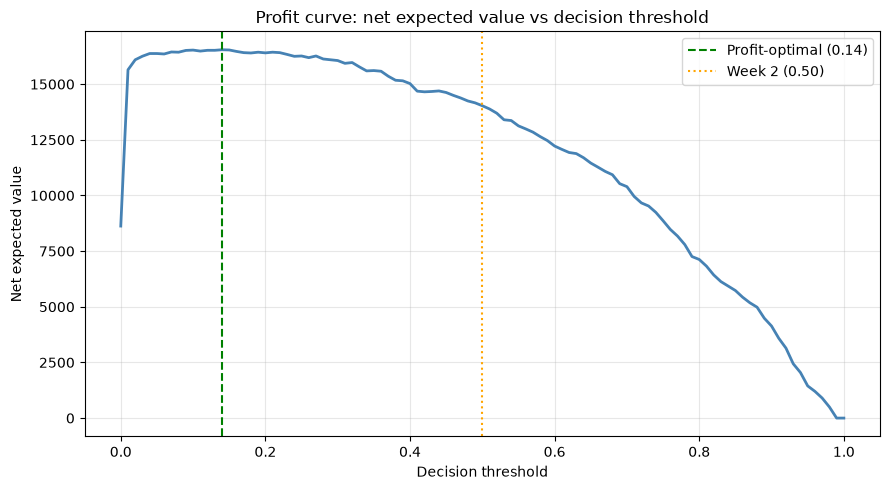

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curve["threshold"], curve["expected_value"], color="steelblue", linewidth=2)
ax.axvline(
    optimal_threshold,
    color="green",
    linestyle="--",
    label=f"Profit-optimal ({optimal_threshold:.2f})",
)
ax.axvline(
    week2_threshold,
    color="orange",
    linestyle=":",
    label=f"Week 2 ({week2_threshold:.2f})",
)
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Net expected value")
ax.set_title("Profit curve: net expected value vs decision threshold")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Comparison vs Week 2

With intervention cost **5** and conversion value **50**, false alarms are relatively cheap compared with missing a buyer. The profit curve therefore peaks at a **lower** threshold than Week 2’s 0.5 (around **0.14** on this test split).

Week 2’s 0.5 still makes sense as a *metric-balanced* operating point (precision/recall), but it leaves money on the table under these cost assumptions because it is more conservative about flagging sessions. If outreach were expensive (higher intervention cost), the peak would move right and get closer to 0.5.

I’m **not** changing `config.yaml` threshold to 0.14 by default, that value is specific to these toy costs. The point of this stretch goal is to show how to pick a threshold from expected value, not to silently overwrite the Week 2 choice.
